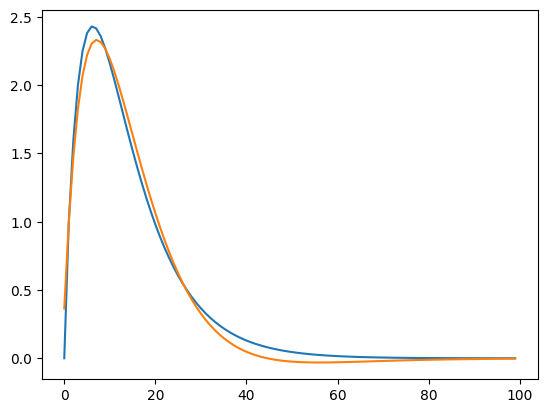

[]


In [2]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import control.matlab as cm
from scipy.signal import cont2discrete , tf2ss

def lagd(a, N):
    v = np.zeros(N)
    Lo = np.zeros(N)
    v[0] = a
    Lo[0] = 1

    for k in range(1, N):
        v[k] = ((-a) ** (k - 1)) * (1 - a * a)
        Lo[k] = (-a) ** (k)

    Lo = np.sqrt((1 - a * a)) * Lo
    # Lo = Lo.reshape(-1,1)
    A = np.zeros((N, N))
    A[:, 0] = v

    for i in range(1, N):
        A[:, i] = np.concatenate([np.zeros(i), v[0:N - i]])
    # print(Lo)
    return A, Lo


if __name__=="__main__":
    num = [1,-0.1]
    den = np.convolve([1, -0.8], [1, -0.9])
    ts = 0.1
    # sys = signal.TransferFunction(num,den)
    sys = signal.dlti(num, den)
    # time, response = signal.step(sys)
    t2 , H = signal.dimpulse(sys)
    H = H[0]
    Nsim = len(t2)
    k = list(range(Nsim))
    
    a = 0.9
    N = 3
    A1,Lo = lagd(a,N)
    L = np.zeros((N, Nsim))
    L[:,0] = Lo
    for kk in range(1,Nsim):
        L[:,kk] = A1@L[:,kk-1]

    c1 = L[0,:]@H
    c2 = L[1,:]@H
    c3 = L[2,:]@H
    H_model = c1*L[0, :] + c2*L[1, :] + c3*L[2, :]

    ## plotting

    plt.plot(t2,H)
    plt.plot(t2,H_model)
    plt.show()

# %%
# if __name__=="__main__":
#     num = [1,-0.1]
#     den = np.convolve([1, -0.8], [1, -0.9])
    
#     sys = signal.TransferFunction(num,den)
#     time, response = signal.step(sys)
#     t2 , H = signal.impulse(sys)
#     print(t2)

print(np.zeros(0))


In [3]:

def dmpc(Ae, Be, a, N, Np, Q, R):
    #Ae and Be are the matrices of the augmented system when integrator is used 
    # They can also be other forms of state space model 
    # a is the parameter of the laguerre network
    # N is the number of terms for each input
    # Np is the prediction horizon
    # Q and R are the cost matrices

    #cost function is J = eta^T E eta + 2 eta^T H x(k_i) 
    #Δui(k) = Li(k)T ηi,

    n, _ = Be.shape
    n_in = 1
    Npa = N[0]  # dimention of eta = sum of all the values of Ns
    E = np.zeros((Npa,Npa))
    H = np.zeros((Npa,n))
    R_para = np.zeros((Npa,Npa))
    n0 = 0
    ne = N[0] 
    for i in range(0,n_in):
        R_para[n0:ne,n0:ne] = R[i,i]*np.eye(N[i],N[i])

    # Now initial condition for the convolution sum 
    Sin = np.zeros((n,Npa))
    
    [A1,Lo] = lagd(a[0],N[0])
    Lo = Lo.reshape(-1, 1)
    # print(Be.shape, Lo.shape)
    Sin[:,0:N[0]] = Be@np.transpose(Lo)
 
    Sc = Sin
    E = np.transpose(Sc)@Q@Sc
    H = np.transpose(Sc)@Q@Ae
## The iteration i is with respect to the prediction horizon 
    for i in range(0,Np):
        Eae = np.linalg.matrix_power(Ae, i+1)
        [A1,Lo] = lagd(a[0],N[0])
        Lo = Lo.reshape(-1,1)
        Sc[:,0:N[0]] = np.linalg.matrix_power(Ae, i-1)@Sc[:,0:N[0]] + Be@np.transpose(np.linalg.matrix_power(A1, i-1)@Lo)
        E = E + np.transpose(Sc)@Q@Sc
        H = H + np.transpose(Sc)@Q@Eae
    E = E + R_para

    return E,H

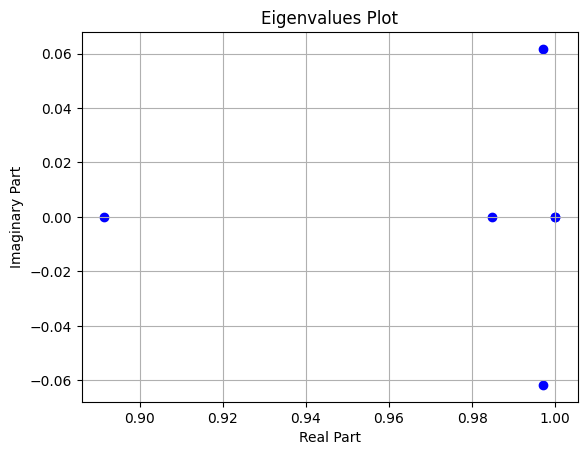

In [21]:
T_eng =  0.460 #0.26  #
K_eng = 0.732
A_f = -1/T_eng
B_f = K_eng/T_eng
C = np.eye(3)
T_hw = 3
Ts = 0.05
T_total = 30
T = int(T_total/Ts)

# Discretize the system
A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
B = np.array([[0], [0], [B_f]])
sys2 = cont2discrete((A,B, C, 0), Ts, method='zoh')
A, B, C, D , dt = sys2

m1,n1 = C.shape
n1,_ = B.shape
n_in = 1

a1 = 0.95
N1 = 5
Np = 50

a = [a1]
N = [N1]

# Augment the state equations 
Ae = np.eye(n1+m1,n1+m1)
Ae[0:n1,0:n1] = A
Ae[n1:n1+m1,0:n1] = C@A
Be = np.zeros((n1+m1,n_in))
Be[0:n1,:] = B
Be[n1:n1+m1,:] = C@B
Ce = np.zeros((m1,n1+m1))
Ce[:,n1:n1+m1] = np.eye(m1,m1)

Q = np.transpose(Ce)@Ce
R = 0.1*np.eye(1,1)

[Omega,Psi]=dmpc(Ae,Be,a,N,Np,Q,R)
L_m=np.zeros((n_in,N[0]))
[A1,L0]=lagd(a[0],N[0])
L0 = L0.reshape(-1,1)
L_m[0,0:N[0]]=np.transpose(L0)

# print(L_m.shape, Omega.shape, Psi.shape)
k1 = np.linalg.solve(Omega, Psi)
K = L_m@k1
Acl=Ae - Be@K

eigenvalues = np.linalg.eigvals(Acl)

# Plot the eigenvalues on the complex plane
plt.scatter(eigenvalues.real, eigenvalues.imag, color='blue')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Eigenvalues Plot')
plt.grid(True)
plt.show()


In [5]:
## without constrain - solution is  -(inv(omega))@phi@xf

def simuuc(xm, u, y, yr, Ae, Be, Ce, N_sim, Omega, Psi, Lzerot):
    m1, n1 = Ce.shape
    # n1, _ = Bp.shape
    n_in = 1
    Lzerot = Lzerot.reshape(-1,1)

    u1 = np.zeros((n_in, N_sim))
    y1 = np.zeros((m1, N_sim))
    deltau1 = np.zeros((n_in, N_sim))
    xf = np.vstack((xm, (y - yr)))

    for kk in range(N_sim):
        eta = -np.linalg.solve(Omega, Psi) @ xf
        Kmpc = np.transpose(Lzerot) @ np.linalg.solve(Omega, Psi)
        Ke = Kmpc[0,3:6].reshape(1,-1)
        deltau = np.transpose(Lzerot) @ eta   # 
        u += deltau
        deltau1[:, kk] = deltau
        u1[:, kk] = u
        xm_old = xm.copy()
        xm = Ae@xm + Be@u
        y = Ce@xm 
        # xf = (Ae - Be@Kmpc) @ xf + Be @ Ke @ yr #xf = Ae @ xf + Be @ deltau
        # y = Ce @ xf

        y1[:,kk] = y.reshape(3,)
        xf = np.vstack((xm - xm_old, y - yr)) #Xf = np.vstack((xm - xm_old, y - sp[:, kk + 1]))

    k = np.arange(N_sim)

    return u1, y1, deltau1, k

In [6]:

T_eng =  0.460 #0.26  #
K_eng = 0.732
A_f = -1/T_eng
B_f = K_eng/T_eng
C = np.eye(3)
T_hw = 3
Ts = 0.05
T_total = 30
T = int(T_total/Ts)


# Discretize the system
A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
B = np.array([[0], [0], [B_f]])
sys2 = cont2discrete((A,B, C, 0), Ts, method='zoh')
A, B, C, D , dt = sys2

m1,n1 = C.shape  # m1 = 3, n1 = 3
n1,n_in = B.shape  # n_in = 1


a1 = 0.9 ; a2 = 0.5 ; a3 = 0.5 ; a4 = 0.5 ; a5 = 0.5
N1 = 15 ; N2 = 10 ; N3 = 10 ; N4 = 10 ; N5 = 10
Np = 100

a = [a1]
N = [N1]

# Augment the state equations 
Ae = np.eye(n1+m1,n1+m1)
Ae[0:n1,0:n1] = A
Ae[n1:n1+m1,0:n1] = C@A
Be = np.zeros((n1+m1,n_in))
Be[0:n1,:] = B
Be[n1:n1+m1,:] = C@B
Ce = np.zeros((m1,n1+m1))
Ce[:,n1:n1+m1] = np.eye(m1,m1)

Q1 = np.transpose(C)@C

Q = 0.5*np.transpose(Ce)@Ce
print(Q.shape)
R = 50*np.eye(1,1)

# Initialize variables
N_sim = 100

u = np.zeros((n_in, 1))
xm = np.array([[50], [5], [0]])
y = xm.copy()
yr = np.array([[0], [0], [0]])

_ , Lz = lagd(a[0], N[0])
Omega,Psi =dmpc(Ae,Be,a,N,Np,Q,R)
u1,y1,deltau1,k=simuuc(xm,u,y,yr,A,B,C,N_sim,Omega,Psi,Lz)

(6, 6)


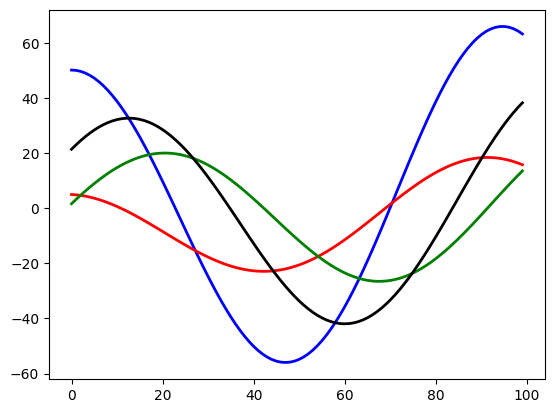

In [7]:
N_sim_plot = range(0,N_sim)
plt.figure()
plt.plot(N_sim_plot, y1[0, :], label='y1', linewidth=2, color='blue')
plt.plot(N_sim_plot, y1[1, :], label='y2', linewidth=2, color='red')
plt.plot(N_sim_plot, y1[2, :], label='y3', linewidth=2, color='green')
plt.plot(N_sim_plot, u1[0], label='u', linewidth=2, color='black')
plt.show()

### Now MPC with constrains 

In [8]:
def Mdu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    Lzerot = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(2, Nc+1):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = np.vstack((M, M_du1))

    return M, Lzerot

a = [0.9]
N = [3]
n_in = 1
Nc = 10

Mdu(a, N, 15, 1)



(array([[ 0.43588989, -0.3923009 ,  0.35307081],
        [ 0.3923009 , -0.27025173,  0.16868939],
        [ 0.35307081, -0.16868939,  0.03338917],
        [ 0.31776373, -0.084737  , -0.06237584],
        [ 0.28598736, -0.01588819, -0.12657589],
        [ 0.25738862,  0.04003823, -0.16584089],
        [ 0.23164976,  0.08493825, -0.18566299],
        [ 0.20848479,  0.12045788, -0.19057054],
        [ 0.18763631,  0.1480242 , -0.18427739],
        [ 0.16887268,  0.16887268, -0.16981086],
        [ 0.15198541,  0.18407122, -0.14962119],
        [ 0.13678687,  0.19454132, -0.12567505],
        [ 0.12310818,  0.2010767 , -0.09953524],
        [ 0.11079736,  0.20435958, -0.07242865],
        [ 0.09971763,  0.20497512, -0.04530381]]),
 array([[ 0.43588989, -0.3923009 ,  0.35307081]]))

QpHild is to solve constrained optimization problem using Hildreth programming 
![Alt text](image.png)

Here eta is set of states 

In [9]:
def QPHild(E, F, M, gamma):
    # inputs are H f A_cons b  in order 
    # Determine which constraints are active and which are inactive
    n1 = M.shape[0]
    m1 = M.shape[1]
    eta = -np.linalg.solve(E, F)
    kk = 0

    for i in range(n1):
        if np.dot(M[i], eta) > gamma[i]:
            kk += 1

    if kk == 0:
        return eta

    P = np.dot(M,np.dot(np.linalg.inv(E),M.T))
    d = np.dot(M,np.dot(np.linalg.inv(E),F)) + gamma

    n, m = d.shape
    x_ini = np.zeros((n, m))
    lam = x_ini
    al = 10
    
    # 40 is the number of iterations to
    for km in range(40):
        lambda_p = np.copy(lam)
        
        for i in range(n):
            w = np.dot(P[i,:],lam) - np.dot(P[i,i],lam[i])
            w = w + d[i]
            la = -w/P[i,i]
            lam[i,0] = max(0,la)
            #print(lam[i,0])
        al = np.dot((lam-lambda_p).T,lam-lambda_p)
        
        if al < 10e-8:
            break

    eta = eta  - np.dot(np.linalg.solve(E, M.T), lam)
    return eta


In [10]:
a = [0.85]
N = [3]
n_in = 1
Nc = 15
Omega,Psi =dmpc(A,B,a,N,Np,Q1,R)
Del_max = 1
Del_min = -1
Nc = 15
x0 = np.array([[50], [5], [0]])
M0, Lzerot = Mdu(a, N,Nc,n_in)
M = np.vstack((M0,-M0))
gamma = np.vstack((Del_max * np.ones((Nc, 1)), -Del_min * np.ones((Nc, 1))))
eta = QPHild(Omega, Psi@x0, M, gamma)
eta

array([[ 2.69542376],
       [ 0.82960109],
       [-0.46295665]])

In [11]:
def simCon(xm, u, y, yr, Ae, Be, Ce, N_sim, Omega, Psi, Lzerot, M0):
    m1, n1 = Ce.shape
    # n1, _ = Bp.shape
    n_in = 1
    Lzerot = Lzerot.reshape(-1,1)
    Del_max = 0.1
    Del_min = -0.1
    Nc = 15   # number of steps on which limit has to be imposed 
    M = np.vstack((M0,-M0))
    gamma = np.vstack((Del_max * np.ones((Nc, 1)), -Del_min * np.ones((Nc, 1))))

    u1 = np.zeros((n_in, N_sim))
    y1 = np.zeros((m1, N_sim))
    deltau1 = np.zeros((n_in, N_sim))
    xf = np.vstack((xm, (y - yr)))

    for kk in range(N_sim):
        eta = QPHild(Omega, Psi@xf, M, gamma)
        # Kmpc = np.transpose(Lzerot) @ np.linalg.solve(Omega, Psi)
        # Ke = Kmpc[0,3:6].reshape(1,-1)
        deltau = np.transpose(Lzerot) @ eta   # 
        u += deltau
        deltau1[:, kk] = deltau
        u1[:, kk] = u
        xm_old = xm.copy()
        xm = Ae@xm + Be@u
        y = Ce@xm 
        # xf = (Ae - Be@Kmpc) @ xf + Be @ Ke @ yr #xf = Ae @ xf + Be @ deltau
        # y = Ce @ xf

        y1[:,kk] = y.reshape(3,)
        xf = np.vstack((xm - xm_old, y - yr)) #Xf = np.vstack((xm - xm_old, y - sp[:, kk + 1]))

    k = np.arange(N_sim)

    return u1, y1, deltau1, k


# For constraints on amplitude of the signals


In [12]:

def Mu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    M1 = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(1, Nc):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = M + M_du1
        M1 = np.vstack((M1, M))

    return M1

a = [0.9]
N = [3]
n_in = 1
Nc = 10

Mu(a, N, 15, 1)



array([[ 0.43588989, -0.3923009 ,  0.35307081],
       [ 0.87177979, -0.78460181,  0.70614163],
       [ 1.26408069, -1.05485354,  0.87483102],
       [ 1.61715151, -1.22354293,  0.90822018],
       [ 1.93491524, -1.30827993,  0.84584434],
       [ 2.2209026 , -1.32416812,  0.71926845],
       [ 2.47829122, -1.28412989,  0.55342756],
       [ 2.70994099, -1.19919164,  0.36776457],
       [ 2.91842577, -1.07873376,  0.17719403],
       [ 3.10606208, -0.93070957, -0.00708336],
       [ 3.27493475, -0.76183689, -0.17689421],
       [ 3.42692016, -0.57776567, -0.3265154 ],
       [ 3.56370703, -0.38322435, -0.45219045],
       [ 3.68681521, -0.18214765, -0.55172569],
       [ 3.79761257,  0.02221193, -0.62415434]])

In [13]:
a = [0.85]
N = [7]
n_in = 1
Nc = 15
Omega,Psi =dmpc(A,B,a,N,Np,Q1,R)
u_prev = 1.2
u_max = 2.5
u_min = -3.5
delu_min = -5
delu_max = 3.5
Nc = 15
x0 = np.array([[50], [5], [0]])
M1,_ = Mdu(a, N,Nc,n_in)
M0 = Mu(a, N,Nc,n_in)
M = np.vstack((M0,-M0, M1, -M1))        
gamma = np.vstack(((u_max - u_prev) * np.ones((Nc, 1)),
                    -(u_min - u_prev) * np.ones((Nc, 1))
                    , delu_max * np.ones((Nc,1))
                    , -delu_min * np.ones((Nc,1))))
print(f"this is Omega {Omega.shape}, Psi {Psi.shape}, M {M.shape}, gamma {gamma.shape}")

eta = QPHild(Omega, Psi@x0, M, gamma)
eta

this is Omega (7, 7), Psi (7, 3), M (60, 7), gamma (60, 1)


array([[-0.51678287],
       [ 4.8238157 ],
       [ 3.57091159],
       [-3.95027546],
       [-8.11212006],
       [-5.02217353],
       [ 7.6504702 ]])

In [14]:
def simCon2(xm, u, y, yr, Ae, Be, Ce, N_sim, Omega, Psi, Lzerot, M0, M1):
    m1, n1 = Ce.shape
    # n1, _ = Bp.shape
    n_in = 1
    Lzerot = Lzerot.reshape(-1,1)

    u_max = 2.5
    u_min = -3.5
    delu_min = -5
    delu_max = 3.5
    Nc = 15   # number of steps on which limit has to be imposed 
    M = np.vstack((M0,-M0,M1, -M1))
    

    u1 = np.zeros((n_in, N_sim))
    y1 = np.zeros((m1, N_sim))
    deltau1 = np.zeros((n_in, N_sim))
    xf = np.vstack((xm, (y - yr)))

    for kk in range(N_sim):
        u_prev = u
        gamma = np.vstack(((u_max - u_prev) * np.ones((Nc, 1)),
                    -(u_min - u_prev) * np.ones((Nc, 1))
                    , delu_max * np.ones((Nc,1))
                    , -delu_min * np.ones((Nc,1))))
        # print(f"this is Omega {Omega.shape}, Psi {Psi.shape}, M {M.shape}, gamma {gamma.shape}")
        eta = QPHild(Omega, Psi@xf, M, gamma)
        # Kmpc = np.transpose(Lzerot) @ np.linalg.solve(Omega, Psi)
        # Ke = Kmpc[0,3:6].reshape(1,-1)
        deltau = np.transpose(Lzerot) @ eta   # 
        u += deltau
        deltau1[:, kk] = deltau
        u1[:, kk] = u
        xm_old = xm.copy()
        xm = Ae@xm + Be@u
        y = Ce@xm 
        # xf = (Ae - Be@Kmpc) @ xf + Be @ Ke @ yr #xf = Ae @ xf + Be @ deltau
        # y = Ce @ xf

        y1[:,kk] = y.reshape(3,)
        xf = np.vstack((xm - xm_old, y - yr)) #Xf = np.vstack((xm - xm_old, y - sp[:, kk + 1]))

    k = np.arange(N_sim)

    return u1, y1, deltau1, k

In [15]:
## Constrints are clamping type
def simCon3(xm, u, y, yr, Ae, Be, Ce, N_sim, Omega, Psi, Lzerot, M0, M1):
    m1, n1 = Ce.shape
    # n1, _ = Bp.shape
    n_in = 1
    Lzerot = Lzerot.reshape(-1,1)

    u_max = 2.5
    u_min = -3.5
    delu_min = -5
    delu_max = 3.5
    Nc = 15   # number of steps on which limit has to be imposed 
    M = np.vstack((M0,-M0,M1, -M1))
    

    u1 = np.zeros((n_in, N_sim))
    y1 = np.zeros((m1, N_sim))
    deltau1 = np.zeros((n_in, N_sim))
    xf = np.vstack((xm, (y - yr)))

    for kk in range(N_sim):
        u_prev = u
        gamma = np.vstack(((u_max - u_prev) * np.ones((Nc, 1)),
                    -(u_min - u_prev) * np.ones((Nc, 1))
                    , delu_max * np.ones((Nc,1))
                    , -delu_min * np.ones((Nc,1))))
        # print(f"this is Omega {Omega.shape}, Psi {Psi.shape}, M {M.shape}, gamma {gamma.shape}")
        eta = QPHild(Omega, Psi@xf, M, gamma)
        # Kmpc = np.transpose(Lzerot) @ np.linalg.solve(Omega, Psi)
        # Ke = Kmpc[0,3:6].reshape(1,-1)
        deltau = np.transpose(Lzerot) @ eta   # 
        if deltau[0] > delu_max:
            deltau[0] = delu_max
        if deltau[0] < delu_min:
            deltau[0] = delu_min
        u += deltau
        if u[0] > u_max:
            u[0] = u_max
        if u[0] < u_min:
            u[0] = u_min
            
        deltau1[:, kk] = deltau
        u1[:, kk] = u
        xm_old = xm.copy()
        xm = Ae@xm + Be@u
        y = Ce@xm 
        # xf = (Ae - Be@Kmpc) @ xf + Be @ Ke @ yr #xf = Ae @ xf + Be @ deltau
        # y = Ce @ xf

        y1[:,kk] = y.reshape(3,)
        xf = np.vstack((xm - xm_old, y - yr)) #Xf = np.vstack((xm - xm_old, y - sp[:, kk + 1]))

    k = np.arange(N_sim)

    return u1, y1, deltau1, k

In [16]:

T_eng =  0.460 #0.26  #
K_eng = 0.732
A_f = -1/T_eng
B_f = K_eng/T_eng
C = np.eye(3)
T_hw = 3
Ts = 0.05
T_total = 10
T = int(T_total/Ts)


# Discretize the system
A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
B = np.array([[0], [0], [B_f]])
sys2 = cont2discrete((A,B, C, 0), Ts, method='zoh')
A, B, C, D , dt = sys2

m1,n1 = C.shape  # m1 = 3, n1 = 3
n1,n_in = B.shape  # n_in = 1


a1 = 0.6  #0.6 and weight 10*Ce@Ce and R - 1, a = 5 - 7  ( 7 is slow, 5 is fast response)
N1 = 8
Np = 100

a = [a1]
N = [N1]

# Augment the state equations 
Ae = np.eye(n1+m1,n1+m1)
Ae[0:n1,0:n1] = A
Ae[n1:n1+m1,0:n1] = C@A
Be = np.zeros((n1+m1,n_in))
Be[0:n1,:] = B
Be[n1:n1+m1,:] = C@B
Ce = np.zeros((m1,n1+m1))
Ce[:,n1:n1+m1] = np.eye(m1,m1)

# Q1 = np.transpose(C)@C

Q = 14*np.transpose(Ce)@Ce
print(Q.shape)
R = 1*np.eye(1,1)

# Initialize variables
N_sim = T

u = np.zeros((n_in, 1))
xm = np.array([[50], [10], [2]])
y = xm.copy()
yr = np.array([[0], [0], [0]])
M1, Lzerot = Mdu(a, N,Nc,n_in)

## If only constrains on del u is needed 
# _ , Lz = lagd(a[0], N[0])
# Omega,Psi =dmpc(Ae,Be,a,N,Np,Q,R)

# u1,y1,deltau1,k=simCon(xm,u,y,yr,A,B,C,N_sim,Omega,Psi,Lz,M0)

# For constrains on del u and U 
M0 = Mu(a, N,Nc,n_in)
_, Lz = lagd(a[0], N[0])
alpha = 1.05
Omega, Psi = dmpc(Ae/alpha, Be/alpha, a, N, Np, Q, R)
# Constraints are defined inside simcon2
u1,y1,deltau1,k=simCon3(xm,u,y,yr,A,B,C,N_sim,Omega,Psi,Lz,M0, M1)



(6, 6)


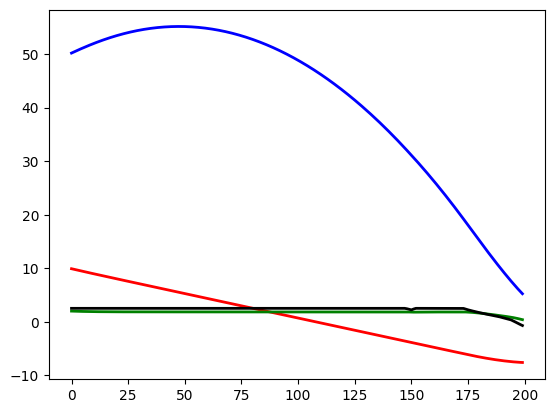

In [17]:
N_sim_plot = range(0,N_sim)
plt.figure()
plt.plot(N_sim_plot, y1[0, :], label='y1', linewidth=2, color='blue')
plt.plot(N_sim_plot, y1[1, :], label='y2', linewidth=2, color='red')
plt.plot(N_sim_plot, y1[2, :], label='y3', linewidth=2, color='green')
plt.plot(N_sim_plot, u1[0], label='u', linewidth=2, color='black')
plt.show()

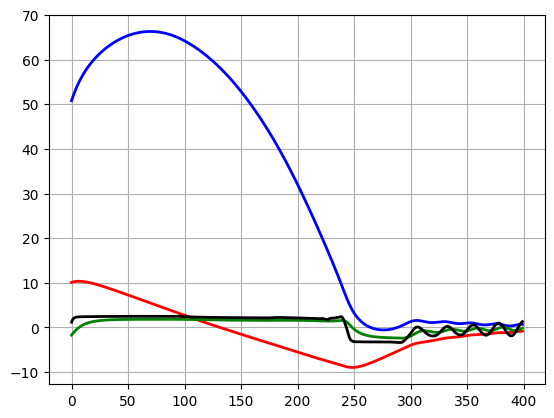

In [45]:
# %%
import numpy as np
import matplotlib.pyplot as plt
# from scipy import signal
import control.matlab as cm
from scipy.signal import cont2discrete 

def lagd(a, N):
    v = np.zeros(N)
    Lo = np.zeros(N)
    v[0] = a
    Lo[0] = 1

    for k in range(1, N):
        v[k] = ((-a) ** (k - 1)) * (1 - a * a)
        Lo[k] = (-a) ** (k)

    Lo = np.sqrt((1 - a * a)) * Lo
    # Lo = Lo.reshape(-1,1)
    A = np.zeros((N, N))
    A[:, 0] = v

    for i in range(1, N):
        A[:, i] = np.concatenate([np.zeros(i), v[0:N - i]])
    # print(Lo)
    return A, Lo

def dmpc(Ae, Be, a, N, Np, Q, R):
    #Ae and Be are the matrices of the augmented system when integrator is used 
    # They can also be other forms of state space model 
    # a is the parameter of the laguerre network
    # N is the number of terms for each input
    # Np is the prediction horizon
    # Q and R are the cost matrices

    #cost function is J = eta^T E eta + 2 eta^T H x(k_i) 
    #Δui(k) = Li(k)T ηi,

    n, _ = Be.shape
    n_in = 1
    Npa = N[0]  # dimention of eta = sum of all the values of Ns
    E = np.zeros((Npa,Npa))
    H = np.zeros((Npa,n))
    R_para = np.zeros((Npa,Npa))
    n0 = 0
    ne = N[0] 
    for i in range(0,n_in):
        R_para[n0:ne,n0:ne] = R[i,i]*np.eye(N[i],N[i])

    # Now initial condition for the convolution sum 
    Sin = np.zeros((n,Npa))
    
    [A1,Lo] = lagd(a[0],N[0])
    Lo = Lo.reshape(-1, 1)
    # print(Be.shape, Lo.shape)
    Sin[:,0:N[0]] = Be@np.transpose(Lo)
 
    Sc = Sin
    E = np.transpose(Sc)@Q@Sc
    H = np.transpose(Sc)@Q@Ae
## The iteration i is with respect to the prediction horizon 
    for i in range(0,Np):
        Eae = np.linalg.matrix_power(Ae, i+1)
        [A1,Lo] = lagd(a[0],N[0])
        Lo = Lo.reshape(-1,1)
        Sc[:,0:N[0]] = np.linalg.matrix_power(Ae, i-1)@Sc[:,0:N[0]] + Be@np.transpose(np.linalg.matrix_power(A1, i-1)@Lo)
        E = E + np.transpose(Sc)@Q@Sc
        H = H + np.transpose(Sc)@Q@Eae
    E = E + R_para

    return E,H

def Mdu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    Lzerot = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(2, Nc+1):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = np.vstack((M, M_du1))

    return M, Lzerot

def QPHild(E, F, M, gamma):
    # inputs are H f A_cons b  in order 
    # Determine which constraints are active and which are inactive
    n1 = M.shape[0]
    m1 = M.shape[1]
    eta = -np.linalg.solve(E, F)
    kk = 0

    for i in range(n1):
        if np.dot(M[i], eta) > gamma[i]:
            kk += 1

    if kk == 0:
        return eta

    P = np.dot(M,np.dot(np.linalg.inv(E),M.T))
    d = np.dot(M,np.dot(np.linalg.inv(E),F)) + gamma

    n, m = d.shape
    x_ini = np.zeros((n, m))
    lam = x_ini
    al = 10
    
    # 40 is the number of iterations to
    for km in range(40):
        lambda_p = np.copy(lam)
        
        for i in range(n):
            w = np.dot(P[i,:],lam) - np.dot(P[i,i],lam[i])
            w = w + d[i]
            la = -w/P[i,i]
            lam[i,0] = max(0,la)
            #print(lam[i,0])
        al = np.dot((lam-lambda_p).T,lam-lambda_p)
        
        if al < 10e-8:
            break

    eta = eta  - np.dot(np.linalg.solve(E, M.T), lam)
    return eta

def Mu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    M1 = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(1, Nc):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = M + M_du1
        M1 = np.vstack((M1, M))

    return M1

def exp_matrix(size, alpha):
    I = np.zeros((size,size))
    for i in range(0,size):
        I[i,i] = pow(alpha,i)

    return I

## Constrints are clamping type
def simCon3(xm, u, y, yr, Ae, Be, Ce, N_sim, Omega, Psi, Lzerot, M0, M1, I):
    m1, n1 = Ce.shape
    # n1, _ = Bp.shape
    n_in = 1
    Lzerot = Lzerot.reshape(-1,1)

    u_max = 2.5
    u_min = -3.5
    delu_min = -5
    delu_max = 3.5
    Nc = 15   # number of steps on which limit has to be imposed 
    M = np.vstack((M0,-M0,M1, -M1))
    M = M@I

    u1 = np.zeros((n_in, N_sim))
    y1 = np.zeros((m1, N_sim))
    deltau1 = np.zeros((n_in, N_sim))
    xf = np.vstack((xm, (y - yr)))

    for kk in range(N_sim):
        u_prev = u
        gamma = np.vstack(((u_max - u_prev) * np.ones((Nc, 1)),
                    -(u_min - u_prev) * np.ones((Nc, 1))
                    , delu_max * np.ones((Nc,1))
                    , -delu_min * np.ones((Nc,1))))
        # print(f"this is Omega {Omega.shape}, Psi {Psi.shape}, M {M.shape}, gamma {gamma.shape}")
        eta = QPHild(Omega, Psi@xm, M, gamma)
        # Kmpc = np.transpose(Lzerot) @ np.linalg.solve(Omega, Psi)
        # Ke = Kmpc[0,3:6].reshape(1,-1)
        deltau = np.transpose(Lzerot) @ eta   # 
        if deltau[0] > delu_max:
            deltau[0] = delu_max
        if deltau[0] < delu_min:
            deltau[0] = delu_min
        u += deltau
        if u[0] > u_max:
            u[0] = u_max
        if u[0] < u_min:
            u[0] = u_min
            
        deltau1[:, kk] = deltau
        u1[:, kk] = u
        xm_old = xm.copy()
        xm = Ae@xm + Be@u
        y = Ce@xm 
        # xf = (Ae - Be@Kmpc) @ xf + Be @ Ke @ yr #xf = Ae @ xf + Be @ deltau
        # y = Ce @ xf

        y1[:,kk] = y.reshape(3,)
        xf = np.vstack((xm - xm_old, y - yr)) #Xf = np.vstack((xm - xm_old, y - sp[:, kk + 1]))

    k = np.arange(N_sim)

    return u1, y1, deltau1, k

if __name__=="__main__":
   
    T_eng =  0.460 #0.26 
    K_eng = 0.732
    A_f = -1/T_eng
    B_f = K_eng/T_eng
    C = np.eye(3)
    T_hw = 3
    Ts = 0.05
    T_total = 20
    T = int(T_total/Ts)


    # Discretize the system
    A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
    B = np.array([[0], [0], [B_f]])
    sys2 = cont2discrete((A,B, C, 0), Ts, method='zoh')
    A, B, C, D , dt = sys2

    m1,n1 = C.shape  # m1 = 3, n1 = 3
    n1,n_in = B.shape  # n_in = 1

    # Augment the state equations 
    Ae = np.eye(n1+m1,n1+m1)
    Ae[0:n1,0:n1] = A
    Ae[n1:n1+m1,0:n1] = C@A
    Be = np.zeros((n1+m1,n_in))
    Be[0:n1,:] = B
    Be[n1:n1+m1,:] = C@B
    Ce = np.zeros((m1,n1+m1))
    Ce[:,n1:n1+m1] = np.eye(m1,m1)

    ###################
    # 
    # Tuning parameters
    #
    ###################
    a1 = 0.7 #0.6 and weight 10*Ce@Ce and R - 1, a = 5 - 7  ( 7 is slow, 5 is fast response)
    N1 = 6
    Np = 30
    alpha = 1.03 ## Exponential weight

    Q = np.transpose(C)@C
    R = 1.2*np.eye(1,1) 
    K, S, E = cm.dlqr(A, B, Q, R)
    Q = (1/alpha)**2*Q + (1-(1/alpha)**2)*S
    R = (1/alpha)**2 * R
    
    a = [a1]
    N = [N1]

    # Initialize variables
    N_sim = T
    Nc = 15

    u = np.zeros((n_in, 1))
    xm = np.array([[50], [10], [-2]])
    y = xm.copy()
    yr = np.array([[0], [0], [0]])
    M1, Lzerot = Mdu(a, N,Nc,n_in)

    M0 = Mu(a, N,Nc,n_in)
    _, Lz = lagd(a[0], N[0])
    I = exp_matrix(N[0], alpha)
    Omega, Psi = dmpc(A/alpha, B/alpha, a, N, Np, Q, R)
    # Constraints are defined inside simcon2
    u1,y1,deltau1,k=simCon3(xm,u,y,yr,A,B,C,N_sim,Omega,Psi,Lz,M0, M1,I)

    N_sim_plot = range(0,N_sim)
    plt.figure()
    plt.plot(N_sim_plot, y1[0, :], label='y1', linewidth=2, color='blue')
    plt.plot(N_sim_plot, y1[1, :], label='y2', linewidth=2, color='red')
    plt.plot(N_sim_plot, y1[2, :], label='y3', linewidth=2, color='green')
    plt.plot(N_sim_plot, u1[0], label='u', linewidth=2, color='black')
    plt.grid(True)
    plt.show()

this is the condition number 6.305573706101964
this is max modulus 0.9572702104967147


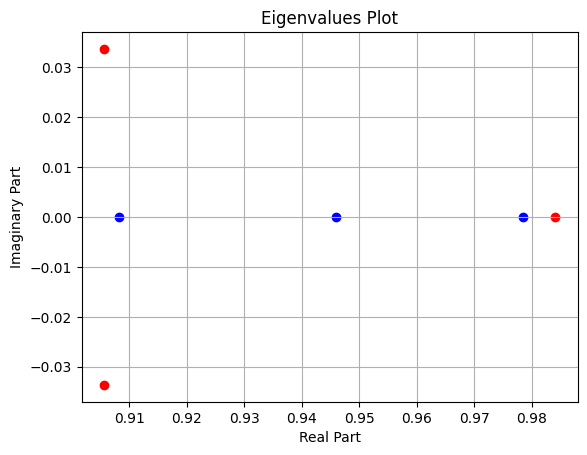

In [43]:
## For choosing alpha for stable eig value
## All the eig values modulus should be less than 1
## can warry a and alpha
import control.matlab as cm
Q = np.transpose(C)@C
R = 1.25*np.eye(1,1)
a = [0.7]
N = [6]

alpha = 1.02
Omega, Psi = dmpc(A/alpha, B/alpha, a, N, Np, Q, R)
condition_number = np.linalg.cond(Omega)
print(f"this is the condition number {condition_number}")

L_m=np.zeros((1,N[0]))
[A1,L0]=lagd(a[0],N[0])
L_m[0,0:N[0]]=np.transpose(L0)

# print(L_m.shape, Omega.shape, Psi.shape)
k1 = np.linalg.solve(Omega, Psi)

K = L_m@k1
Acl=A - B@K

Q = np.transpose(C)@C
_, _, E = cm.dlqr(A, B, Q, R)

eigenvalues = np.linalg.eigvals(Acl)
modi = np.zeros((6,1))
i = 0
for eig in eigenvalues:
    mod = eig.real **2 + eig.imag **2
    modi[i] = mod**0.5
    
print( f"this is max modulus {np.max(mod)}")

# Plot the eigenvalues on the complex plane
plt.scatter(eigenvalues.real, eigenvalues.imag, color='blue')
plt.scatter(E.real, E.imag, color='red')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Eigenvalues Plot')
plt.grid(True)
plt.show()

In [20]:
for i in range (1,10):
    Q = (i/100)*np.transpose(Ce)@Ce
    R = i*10*np.eye(1,1)

    alpha = 1.02
    Omega, Psi = dmpc(Ae/alpha, Be/alpha, a, N, Np, Q, R)
    condition_number = np.linalg.cond(Omega)
    print(f"this is the condition number {condition_number}")

this is the condition number 3.1262101977018437
this is the condition number 3.1262101977018437
this is the condition number 3.126210197701843
this is the condition number 3.1262101977018437
this is the condition number 3.126210197701842
this is the condition number 3.126210197701843
this is the condition number 3.1262101977018433
this is the condition number 3.1262101977018437
this is the condition number 3.126210197701842
